## Mount Google Drive & Paths

In [12]:

from google.colab import drive
drive.mount('/content/drive')

import os

# Root path (change ONLY if your folder name is different)
BASE_PATH = "/content/drive/MyDrive/Deep-Learning/Study06/Heuristics"

NOTEBOOK_PATH = os.path.join(BASE_PATH, "notebooks")
VISUALS_PATH = os.path.join(BASE_PATH, "Visuals")

# Create folders if not exist (safe practice)
os.makedirs(NOTEBOOK_PATH, exist_ok=True)
os.makedirs(VISUALS_PATH, exist_ok=True)

print("Notebook Path:", NOTEBOOK_PATH)
print("Visuals Path:", VISUALS_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Notebook Path: /content/drive/MyDrive/Deep-Learning/Study06/Heuristics/notebooks
Visuals Path: /content/drive/MyDrive/Deep-Learning/Study06/Heuristics/Visuals


## save plot

In [13]:

def save_plot(filename):
    filepath = os.path.join(VISUALS_PATH, filename)
    plt.savefig(filepath, bbox_inches='tight', dpi=300)
    print(f"Saved: {filepath}")

##  Heuristics for Improving the Backpropagation Algorithm

## Lab Objectives
In this lab, you will study practical heuristics that improve backpropagation training:
- learning rate tuning
- learning rate scheduling
- reduce on plateau
- adaptive optimizers

The goal is to observe how these heuristics affect training speed, stability, and final accuracy.

## Learning Outcomes

1. explain why a bad learning rate causes slow learning or divergence,
2. train a simple neural network using backpropagation,
3. compare fixed learning rates with scheduled learning rates,
4. apply StepLR, ExponentialLR, and ReduceLROnPlateau,
5. compare SGD and Adam,
6. interpret loss curves and accuracy results.

In [14]:
# -*- coding: utf-8 -*-
# Install packages if needed in Colab
# In most Colab environments these are already available.
!pip -q install torch torchvision scikit-learn matplotlib



In [15]:
import copy
import math
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Part 1 - Create a Simple Dataset
We use the `make_moons` dataset because:
- it is small and fast for Colab,
- it is non-linear,
- it clearly shows how training behavior changes with different heuristics.


Train size: 840
Validation size: 180
Test size: 180


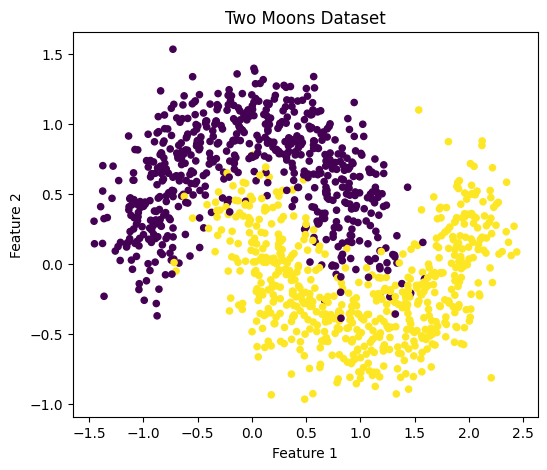

In [16]:
# Create dataset
X, y = make_moons(n_samples=1200, noise=0.22, random_state=42)

# Train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20)
plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



## Part 2 - Define the Neural Network
This is a small multilayer perceptron trained with backpropagation.

In [17]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )
    def forward(self, x):
        return self.net(x)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            total_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, total_correct / total

def train_model(
    optimizer_name="SGD",
    lr=0.01,
    epochs=40,
    scheduler_type=None,
    step_size=10,
    gamma=0.1,
    plateau_patience=3
):
    model = SimpleMLP().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "Momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError("Unsupported optimizer")

    scheduler = None
    if scheduler_type == "step":
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    elif scheduler_type == "exponential":
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    elif scheduler_type == "plateau":
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=gamma, patience=plateau_patience
        )

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "lr": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss, running_correct, total = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = running_correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if scheduler_type == "plateau":
            scheduler.step(val_loss)
        elif scheduler is not None:
            scheduler.step()

    test_loss, test_acc = evaluate(model, test_loader, criterion)
    return model, history, test_loss, test_acc

def plot_history(histories, title_prefix="Experiment"):
    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    for name, hist in histories.items():
        plt.plot(hist["train_loss"], label=f"{name} Train")
        plt.plot(hist["val_loss"], linestyle="--", label=f"{name} Val")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,3,2)
    for name, hist in histories.items():
        plt.plot(hist["val_acc"], label=name)
    plt.title(f"{title_prefix} - Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()


    plt.subplot(1,3,3)
    for name, hist in histories.items():
        plt.plot(hist["lr"], label=name)
    plt.title(f"{title_prefix} - Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.legend()

    plt.tight_layout()


    filename = title_prefix.replace(" ", "_").lower() + ".png"
    save_plot(filename)

    plt.show()

## Part 3 - Experiment 1: Effect of Fixed Learning Rate

if the learning rate is:
- too small -> training becomes very slow,
- too large -> training may oscillate or diverge,
- moderate -> training becomes stable and effective.

Now compare three cases:
- `0.0001` (too small)
- `0.01` (good/moderate)
- `1.0` (too large)


Learning Rate = 0.0001  | Test Loss = 0.6735 | Test Acc = 0.7222
Learning Rate = 0.01    | Test Loss = 0.2911 | Test Acc = 0.8889
Learning Rate = 1.0     | Test Loss = 0.1153 | Test Acc = 0.9500
Saved: /content/drive/MyDrive/Deep-Learning/Study06/Heuristics/Visuals/experiment_1.png


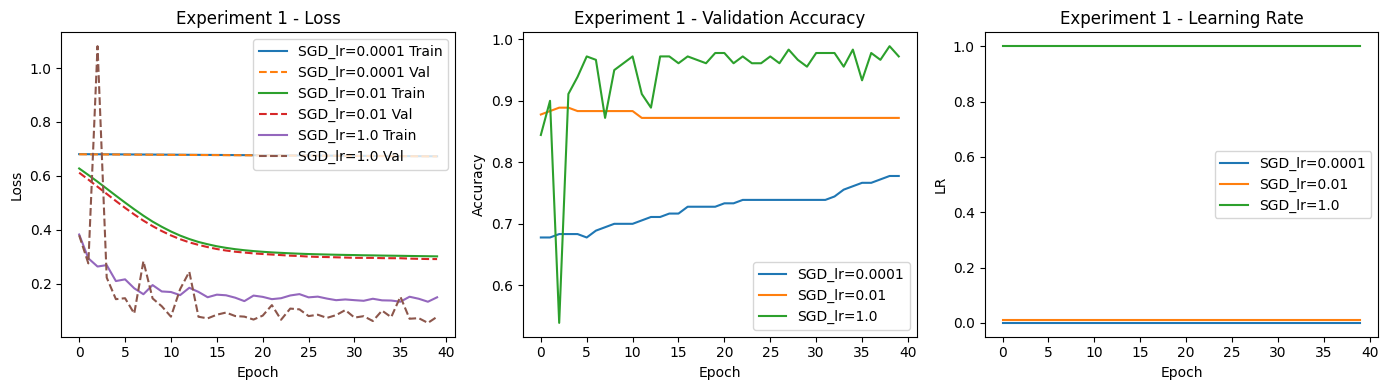

In [18]:
results_exp1 = {}

for lr in [0.0001, 0.01, 1.0]:
    _, hist, test_loss, test_acc = train_model(
        optimizer_name="SGD",
        lr=lr,
        epochs=40,
        scheduler_type=None
    )
    results_exp1[f"SGD_lr={lr}"] = hist
    print(f"Learning Rate = {lr:<7} | Test Loss = {test_loss:.4f} | Test Acc = {test_acc:.4f}")

plot_history(results_exp1, title_prefix="Experiment 1")

## Part 4 - Experiment 2: Step Decay

- use a larger learning rate at the beginning,
- reduce it after fixed epochs,
- help training move fast first and fine-tune later.

Example in lecture:
- Epoch 1-10 -> higher LR
- Epoch 11-20 -> lower LR
- Epoch 21-30 -> even lower LR

Fixed SGD   | Test Loss = 0.2987 | Test Acc = 0.8889
Step Decay  | Test Loss = 0.2644 | Test Acc = 0.9000
Saved: /content/drive/MyDrive/Deep-Learning/Study06/Heuristics/Visuals/experiment_2.png


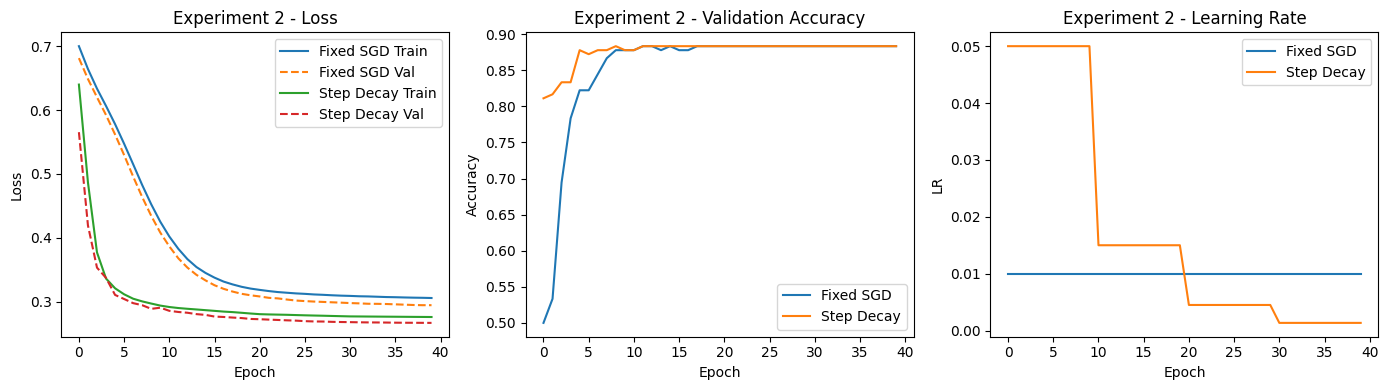

In [19]:
results_exp2 = {}

# Baseline fixed SGD
_, hist_fixed, test_loss_fixed, test_acc_fixed = train_model(
    optimizer_name="SGD", lr=0.01, epochs=40, scheduler_type=None
)
results_exp2["Fixed SGD"] = hist_fixed

# SGD + StepLR
_, hist_step, test_loss_step, test_acc_step = train_model(
    optimizer_name="SGD", lr=0.05, epochs=40,
    scheduler_type="step", step_size=10, gamma=0.3
)
results_exp2["Step Decay"] = hist_step

print(f"Fixed SGD   | Test Loss = {test_loss_fixed:.4f} | Test Acc = {test_acc_fixed:.4f}")
print(f"Step Decay  | Test Loss = {test_loss_step:.4f} | Test Acc = {test_acc_step:.4f}")

plot_history(results_exp2, title_prefix="Experiment 2")

## Part 5 - Experiment 3: Exponential Decay

Lecture idea:
- learning rate decreases smoothly instead of dropping suddenly.

This often gives a gradual transition from large steps to small steps.

Fixed SGD          | Test Loss = 0.2910 | Test Acc = 0.8889
Exponential Decay  | Test Loss = 0.2726 | Test Acc = 0.8889
Saved: /content/drive/MyDrive/Deep-Learning/Study06/Heuristics/Visuals/experiment_3.png


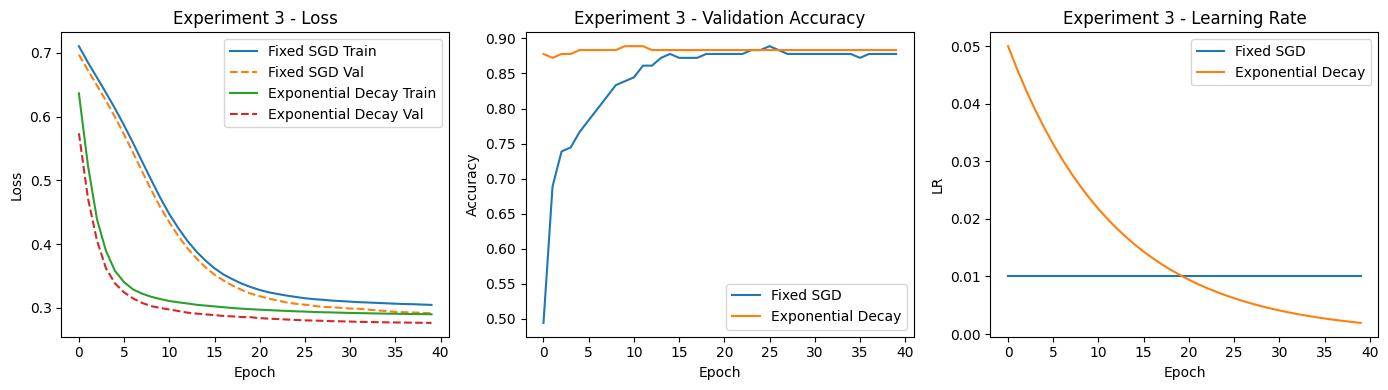

In [20]:
results_exp3 = {}

_, hist_fixed2, test_loss_fixed2, test_acc_fixed2 = train_model(
    optimizer_name="SGD", lr=0.01, epochs=40, scheduler_type=None
)
results_exp3["Fixed SGD"] = hist_fixed2

_, hist_exp, test_loss_exp, test_acc_exp = train_model(
    optimizer_name="SGD", lr=0.05, epochs=40,
    scheduler_type="exponential", gamma=0.92
)
results_exp3["Exponential Decay"] = hist_exp

print(f"Fixed SGD          | Test Loss = {test_loss_fixed2:.4f} | Test Acc = {test_acc_fixed2:.4f}")
print(f"Exponential Decay  | Test Loss = {test_loss_exp:.4f} | Test Acc = {test_acc_exp:.4f}")

plot_history(results_exp3, title_prefix="Experiment 3")

## Part 6 - Experiment 4: Reduce on Plateau

Lecture idea:
- reduce the learning rate only when the model stops improving,
- useful when validation loss becomes flat for a few epochs.

This is more adaptive than fixed schedules.


Fixed SGD         | Test Loss = 0.2941 | Test Acc = 0.8778
ReduceOnPlateau   | Test Loss = 0.1791 | Test Acc = 0.9500
Saved: /content/drive/MyDrive/Deep-Learning/Study06/Heuristics/Visuals/experiment_4.png


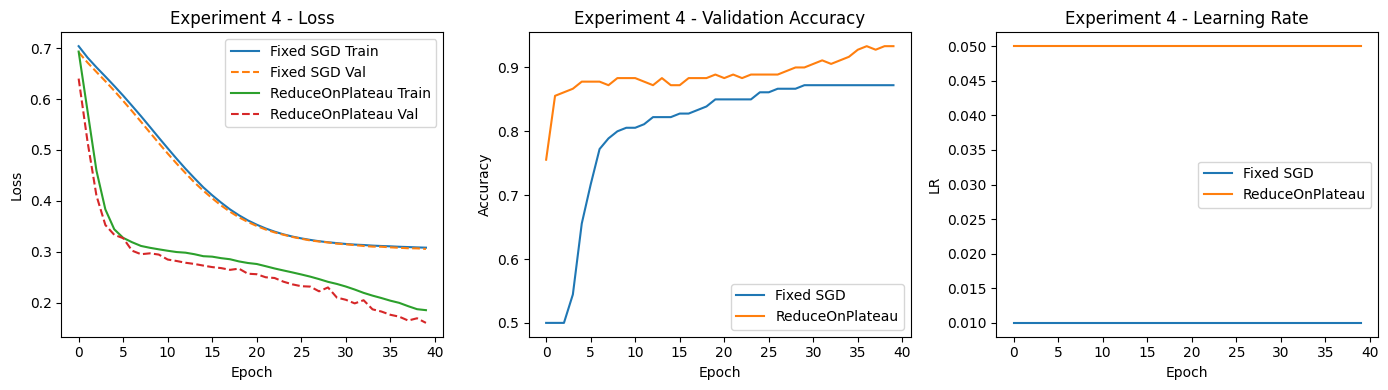

In [21]:
results_exp4 = {}

_, hist_fixed3, test_loss_fixed3, test_acc_fixed3 = train_model(
    optimizer_name="SGD", lr=0.01, epochs=40, scheduler_type=None
)
results_exp4["Fixed SGD"] = hist_fixed3

_, hist_plateau, test_loss_plateau, test_acc_plateau = train_model(
    optimizer_name="SGD", lr=0.05, epochs=40,
    scheduler_type="plateau", gamma=0.5, plateau_patience=3
)
results_exp4["ReduceOnPlateau"] = hist_plateau

print(f"Fixed SGD         | Test Loss = {test_loss_fixed3:.4f} | Test Acc = {test_acc_fixed3:.4f}")
print(f"ReduceOnPlateau   | Test Loss = {test_loss_plateau:.4f} | Test Acc = {test_acc_plateau:.4f}")

plot_history(results_exp4, title_prefix="Experiment 4")

## Part 7 - Experiment 5: Adaptive Optimizers

Lecture idea:
Adaptive optimizers adjust learning rate automatically for parameters.

We compare:
- SGD
- Momentum
- RMSprop
- Adam

SGD       | Test Loss = 0.2958 | Test Acc = 0.8778
Momentum  | Test Loss = 0.1477 | Test Acc = 0.9611
RMSprop   | Test Loss = 0.1550 | Test Acc = 0.9611
Adam      | Test Loss = 0.1177 | Test Acc = 0.9500
Saved: /content/drive/MyDrive/Deep-Learning/Study06/Heuristics/Visuals/experiment_5.png


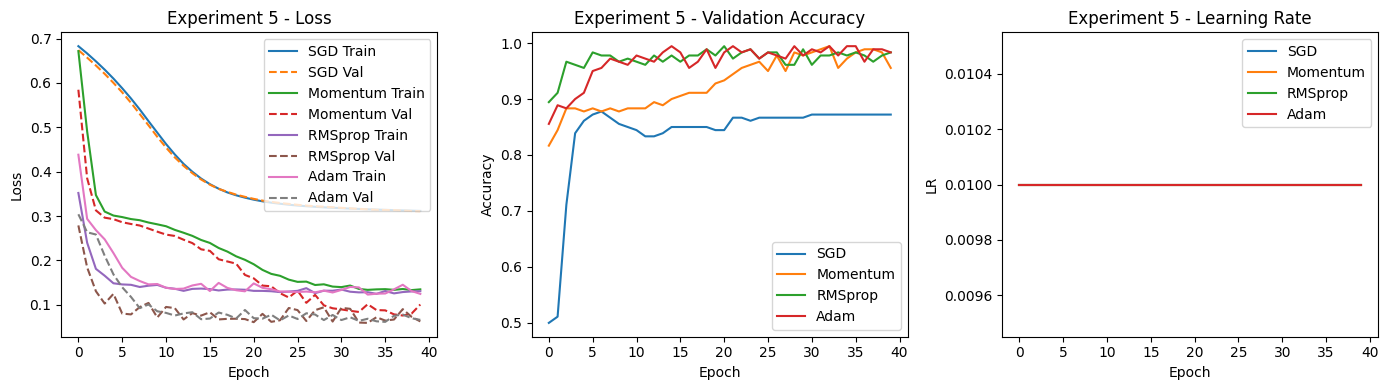

In [22]:
results_exp5 = {}

for opt_name, lr in [("SGD", 0.01), ("Momentum", 0.01), ("RMSprop", 0.01), ("Adam", 0.01)]:
    _, hist, test_loss, test_acc = train_model(
        optimizer_name=opt_name,
        lr=lr,
        epochs=40,
        scheduler_type=None
    )
    results_exp5[opt_name] = hist
    print(f"{opt_name:<9} | Test Loss = {test_loss:.4f} | Test Acc = {test_acc:.4f}")

plot_history(results_exp5, title_prefix="Experiment 5")

## Part 8 - Visual Decision Boundary (Optional Enrichment)
This helps to **see** how the trained model separates classes.

Saved: /content/drive/MyDrive/Deep-Learning/Study06/Heuristics/Visuals/decision_boundary_-_adam.png


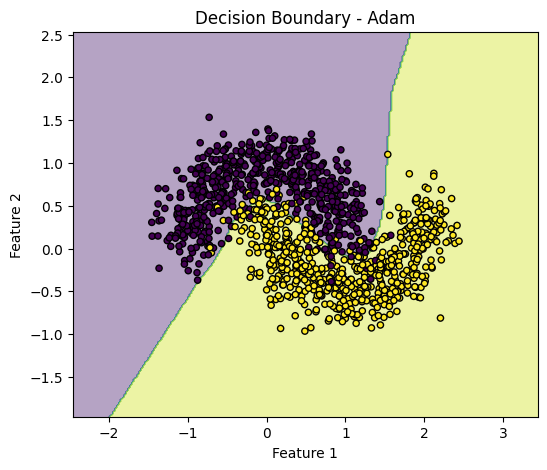

In [23]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    model.eval()
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    grid_t = torch.tensor(grid_scaled, dtype=torch.float32).to(device)

    with torch.no_grad():
        preds = model(grid_t).argmax(dim=1).cpu().numpy()

    zz = preds.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, zz, alpha=0.4)
    plt.scatter(X[:,0], X[:,1], c=y, s=20, edgecolors="k")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    filename = title.replace(" ", "_").lower() + ".png"
    save_plot(filename)
    plt.show()

best_model, _, _, _ = train_model(optimizer_name="Adam", lr=0.001, epochs=40)
plot_decision_boundary(best_model, X, y, title="Decision Boundary - Adam")


## Viva / Discussion Questions
1. Why does a very high learning rate cause oscillation?
2. Why does a very low learning rate slow convergence?
3. What is the difference between fixed learning rate and scheduled learning rate?
4. Why is ReduceOnPlateau called a smart strategy?
5. How is Adam different from standard SGD?
6. Which method was best in your experiment and why?
